Импорты, seed и устройство

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


Загрузка датасета EMNIST и определение transform

In [43]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


dataset_train = datasets.EMNIST(root='./data',
                          train=True,
                          download=True,
                          transform=transforms.ToTensor(),
                          split="balanced")
dataset_test = datasets.EMNIST(root='./data',
                          train=False,
                          download=True,
                          transform=transforms.ToTensor(),
                          split="balanced")

Разбиение train/val из train-части с фиксированным seed

In [44]:
train_ratio = 0.8
train_size = int(train_ratio * len(dataset_train))
val_size = len(dataset_train) - train_size

generator = torch.Generator().manual_seed(SEED)
dataset_train, dataset_val = random_split(
    dataset_train,
    [train_size, val_size],
    generator=generator
)

Создать DataLoader для train/val/test

In [57]:
batch_size = 64

train_loader = DataLoader(
    dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    dataset_val,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    dataset_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [46]:
x_batch, y_batch = next(iter(train_loader))

print(f"Количество батчей: {len(train_loader)}")
print(f"Размер батча: {x_batch.shape[0]}")
print(f"Shape images: {x_batch.shape}")
print(f"Shape labels: {y_batch.shape}")
print(f"Тип данных images: {x_batch.dtype}")
print(f"Тип данных labels: {y_batch.dtype}")
print(f"Уникальные метки в батче: {torch.unique(y_batch).tolist()}")
print(f"images min value: {x_batch.min():.4f}")
print(f"images max value: {x_batch.max():.4f}")
print(f"images mean value: {x_batch.mean():.4f}")
print(f"images std value: {x_batch.std():.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Количество батчей: 1410
Размер батча: 64
Shape images: torch.Size([64, 1, 28, 28])
Shape labels: torch.Size([64])
Тип данных images: torch.float32
Тип данных labels: torch.int64
Уникальные метки в батче: [0, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 17, 18, 19, 23, 24, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 46]
images min value: 0.0000
images max value: 1.0000
images mean value: 0.1919
images std value: 0.3483


Класс MLP

In [54]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_sizes=[512, 256], num_classes=47, dropout_rate=0.2, use_batchnorm=False):
        super(MLP, self).__init__()

        layers = []

        layers.append(nn.Flatten())

        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(*layers)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.network(x)

    def get_features(self, x):
        for layer in self.network[:-1]:
            x = layer(x)
        return x

input_size = 28 * 28
num_classes = 47
model = MLP(
    input_size=input_size,
    hidden_sizes=[512, 256, 128],
    num_classes=num_classes,
    dropout_rate=0.2
).to(device)


Реализованные функции evaluate, model.eval и torch.no_grad

In [48]:
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_accuracy = 0.0
    total_batches = len(train_loader)

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_accuracy += calculate_accuracy(outputs, labels)

        if (batch_idx + 1) % 200 == 0:
            print(f'  Batch [{batch_idx+1}/{total_batches}], '
                  f'Loss: {loss.item():.4f}, '
                  f'Acc: {calculate_accuracy(outputs, labels):.4f}')

    epoch_loss = running_loss / total_batches
    epoch_accuracy = running_accuracy / total_batches

    return epoch_loss, epoch_accuracy

def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_accuracy = 0.0
    total_batches = len(val_loader)

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_accuracy += calculate_accuracy(outputs, labels)

    avg_loss = running_loss / total_batches
    avg_accuracy = running_accuracy / total_batches

    return avg_loss, avg_accuracy

In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

train_losses = []
train_accs = []
val_losses = []
val_accs = []

print(f"Начало обучения на устройстве: {device}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print("=" * 70)

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print("-" * 70)

    # Обучение
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Валидация
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    # Сохранение истории
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

Начало обучения на устройстве: cpu
Train batches: 1410, Val batches: 353

Epoch [1/10]
----------------------------------------------------------------------
  Batch [200/1410], Loss: 1.4531, Acc: 0.5469
  Batch [400/1410], Loss: 1.2796, Acc: 0.5781
  Batch [600/1410], Loss: 1.0819, Acc: 0.6250
  Batch [800/1410], Loss: 0.8980, Acc: 0.6875
  Batch [1000/1410], Loss: 0.8041, Acc: 0.7031
  Batch [1200/1410], Loss: 0.7753, Acc: 0.7500
  Batch [1400/1410], Loss: 0.9434, Acc: 0.6719

Train Loss: 1.2057, Train Acc: 0.6392
Val Loss:   0.6599, Val Acc:   0.7866

Epoch [2/10]
----------------------------------------------------------------------
  Batch [200/1410], Loss: 0.8554, Acc: 0.6719
  Batch [400/1410], Loss: 0.8488, Acc: 0.7656
  Batch [600/1410], Loss: 0.5741, Acc: 0.8281
  Batch [800/1410], Loss: 0.8416, Acc: 0.6719
  Batch [1000/1410], Loss: 0.5105, Acc: 0.8438
  Batch [1200/1410], Loss: 0.6664, Acc: 0.8281
  Batch [1400/1410], Loss: 0.6263, Acc: 0.7344

Train Loss: 0.7147, Train Acc

In [56]:
import time


def make_optimizer(model, kind="adam", lr=1e-3, weight_decay=0.0):
    """Создание оптимизатора"""
    kind = kind.lower()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {kind}")


class EarlyStopping:
    """Ранняя остановка"""
    def __init__(self, patience=5):
        self.patience = patience
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def fit(model, train_loader, val_loader, optimizer, criterion, epochs=10,
        early_stopping=None, verbose=True):
    """Полный цикл обучения"""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # Обучение
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        # Валидация
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        dt = time.time() - t0

        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                  f"val loss {val_loss:.4f}, acc {val_acc:.3f} | {dt:.1f}s")

        # Early stopping
        if early_stopping is not None:
            should_stop = early_stopping.step(val_acc, model)
            if should_stop:
                if verbose:
                    print(f"EarlyStopping: остановка на эпохе {epoch} "
                          f"Лучший val_acc={early_stopping.best_score:.4f}")
                early_stopping.restore_best(model)
                break

    return history

EPOCHS=10

E1 (base)

In [51]:
e1_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
               num_classes=47, dropout_rate=0.0).to(device)
e1_opt = make_optimizer(e1_model, kind="adam", lr=1e-3, weight_decay=0.0)
e1_hist = fit(e1_model, train_loader, val_loader, e1_opt, criterion, epochs=EPOCHS)

  Batch [200/1410], Loss: 1.2302, Acc: 0.6562
  Batch [400/1410], Loss: 1.1463, Acc: 0.6250
  Batch [600/1410], Loss: 0.6119, Acc: 0.8125
  Batch [800/1410], Loss: 0.8442, Acc: 0.7656
  Batch [1000/1410], Loss: 0.7999, Acc: 0.7812
  Batch [1200/1410], Loss: 0.7936, Acc: 0.7656
  Batch [1400/1410], Loss: 0.4874, Acc: 0.8125
Epoch 01/10 | train loss 0.9287, acc 0.719 | val loss 0.6072, acc 0.803 | 39.5s
  Batch [200/1410], Loss: 0.6118, Acc: 0.8281
  Batch [400/1410], Loss: 0.5004, Acc: 0.8750
  Batch [600/1410], Loss: 0.4156, Acc: 0.8750
  Batch [800/1410], Loss: 0.6015, Acc: 0.7969
  Batch [1000/1410], Loss: 0.4696, Acc: 0.7969
  Batch [1200/1410], Loss: 0.5058, Acc: 0.8438
  Batch [1400/1410], Loss: 0.4870, Acc: 0.8125
Epoch 02/10 | train loss 0.5330, acc 0.820 | val loss 0.5102, acc 0.830 | 36.1s
  Batch [200/1410], Loss: 0.4107, Acc: 0.8594
  Batch [400/1410], Loss: 0.4734, Acc: 0.8438
  Batch [600/1410], Loss: 0.5840, Acc: 0.8281
  Batch [800/1410], Loss: 0.4383, Acc: 0.8594
  Batc

E2 (Dropout)

In [58]:
e2_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
               num_classes=47, dropout_rate=0.3).to(device)
e2_opt = make_optimizer(e2_model, kind="adam", lr=1e-3, weight_decay=0.0)
e2_hist = fit(e2_model, train_loader, val_loader, e2_opt, criterion, epochs=EPOCHS)

  Batch [200/1410], Loss: 2.2645, Acc: 0.3750
  Batch [400/1410], Loss: 1.1719, Acc: 0.6562
  Batch [600/1410], Loss: 0.9410, Acc: 0.7031
  Batch [800/1410], Loss: 0.7330, Acc: 0.8281
  Batch [1000/1410], Loss: 1.1782, Acc: 0.5781
  Batch [1200/1410], Loss: 1.3291, Acc: 0.5625
  Batch [1400/1410], Loss: 0.9230, Acc: 0.7344
Epoch 01/10 | train loss 1.3885, acc 0.590 | val loss 0.7049, acc 0.768 | 36.1s
  Batch [200/1410], Loss: 0.9407, Acc: 0.7188
  Batch [400/1410], Loss: 0.9512, Acc: 0.6875
  Batch [600/1410], Loss: 0.8986, Acc: 0.7500
  Batch [800/1410], Loss: 0.5912, Acc: 0.8438
  Batch [1000/1410], Loss: 0.7460, Acc: 0.7344
  Batch [1200/1410], Loss: 0.5837, Acc: 0.7500
  Batch [1400/1410], Loss: 0.6982, Acc: 0.7812
Epoch 02/10 | train loss 0.8390, acc 0.735 | val loss 0.5881, acc 0.804 | 35.9s
  Batch [200/1410], Loss: 0.6222, Acc: 0.7969
  Batch [400/1410], Loss: 0.6183, Acc: 0.8125
  Batch [600/1410], Loss: 0.7247, Acc: 0.8281
  Batch [800/1410], Loss: 0.7325, Acc: 0.7812
  Batc

E3 (BatchNorm)

In [59]:
e3_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
               num_classes=47, dropout_rate=0.0).to(device)
e3_opt = make_optimizer(e3_model, kind="adam", lr=1e-3, weight_decay=0.0)
e3_hist = fit(e3_model, train_loader, val_loader, e3_opt, criterion, epochs=EPOCHS)

  Batch [200/1410], Loss: 1.0686, Acc: 0.7031
  Batch [400/1410], Loss: 1.4525, Acc: 0.7031
  Batch [600/1410], Loss: 0.7590, Acc: 0.7969
  Batch [800/1410], Loss: 0.6907, Acc: 0.8438
  Batch [1000/1410], Loss: 0.7650, Acc: 0.7500
  Batch [1200/1410], Loss: 0.6318, Acc: 0.7656
  Batch [1400/1410], Loss: 0.5726, Acc: 0.8125
Epoch 01/10 | train loss 0.9156, acc 0.720 | val loss 0.6478, acc 0.792 | 32.8s
  Batch [200/1410], Loss: 0.5127, Acc: 0.8438
  Batch [400/1410], Loss: 0.3550, Acc: 0.8281
  Batch [600/1410], Loss: 0.5330, Acc: 0.8438
  Batch [800/1410], Loss: 0.4903, Acc: 0.8281
  Batch [1000/1410], Loss: 0.5727, Acc: 0.7969
  Batch [1200/1410], Loss: 0.4137, Acc: 0.8906
  Batch [1400/1410], Loss: 0.4887, Acc: 0.7969
Epoch 02/10 | train loss 0.5258, acc 0.822 | val loss 0.5194, acc 0.829 | 32.4s
  Batch [200/1410], Loss: 0.4787, Acc: 0.8438
  Batch [400/1410], Loss: 0.4146, Acc: 0.7969
  Batch [600/1410], Loss: 0.3365, Acc: 0.8594
  Batch [800/1410], Loss: 0.3361, Acc: 0.8281
  Batc

E4 (EarlyStopping)

In [61]:
e2_best = max(e2_hist['val_acc'])
e3_best = max(e3_hist['val_acc'])


if e2_best >= e3_best:
    print("Выбираем Dropout")
    e4_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
                   num_classes=47, dropout_rate=0.3).to(device)
else:
    print("Выбираем Base")
    e4_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
                   num_classes=47, dropout_rate=0.0).to(device)

e4_opt = make_optimizer(e4_model, kind="adam", lr=1e-3, weight_decay=0.0)
early_stopper = EarlyStopping(patience=5)
e4_hist = fit(e4_model, train_loader, val_loader, e4_opt, criterion,
              epochs=EPOCHS, early_stopping=early_stopper)

Выбираем Base
  Batch [200/1410], Loss: 1.4122, Acc: 0.5312
  Batch [400/1410], Loss: 1.0719, Acc: 0.7344
  Batch [600/1410], Loss: 0.8606, Acc: 0.7344
  Batch [800/1410], Loss: 0.8304, Acc: 0.7344
  Batch [1000/1410], Loss: 0.6960, Acc: 0.7656
  Batch [1200/1410], Loss: 0.9806, Acc: 0.7031
  Batch [1400/1410], Loss: 0.8391, Acc: 0.7031
Epoch 01/10 | train loss 0.9209, acc 0.719 | val loss 0.6171, acc 0.801 | 31.9s
  Batch [200/1410], Loss: 0.4235, Acc: 0.8125
  Batch [400/1410], Loss: 0.5137, Acc: 0.7812
  Batch [600/1410], Loss: 0.3741, Acc: 0.8750
  Batch [800/1410], Loss: 0.5423, Acc: 0.7969
  Batch [1000/1410], Loss: 0.6920, Acc: 0.7500
  Batch [1200/1410], Loss: 0.5062, Acc: 0.8281
  Batch [1400/1410], Loss: 0.5176, Acc: 0.8906
Epoch 02/10 | train loss 0.5309, acc 0.820 | val loss 0.5273, acc 0.824 | 34.1s
  Batch [200/1410], Loss: 0.4078, Acc: 0.8438
  Batch [400/1410], Loss: 0.4425, Acc: 0.8281
  Batch [600/1410], Loss: 0.3614, Acc: 0.8906
  Batch [800/1410], Loss: 0.6788, Acc:

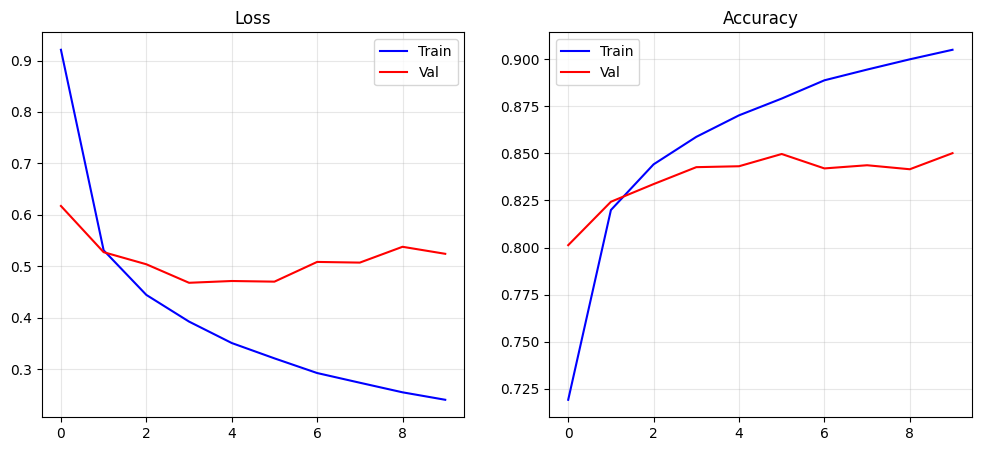

In [64]:
import os
os.makedirs('figures', exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(e4_hist['train_loss'], 'b-', label='Train')
ax1.plot(e4_hist['val_loss'], 'r-', label='Val')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(e4_hist['train_acc'], 'b-', label='Train')
ax2.plot(e4_hist['val_acc'], 'r-', label='Val')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.savefig('figures/curves_best.png', dpi=300, bbox_inches='tight')
plt.show()

In [80]:
os.makedirs('artifacts', exist_ok=True)
os.makedirs('figures', exist_ok=True)


best_model = MLP(
    input_size=28*28,
    hidden_sizes=[512, 256, 128],
    num_classes=47,
    dropout_rate=0.0
).to(device)

best_model.load_state_dict(torch.load('artifacts/best_model.pt'))
best_model.eval()

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

FileNotFoundError: [Errno 2] No such file or directory: 'artifacts/best_model.pt'

In [82]:
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)


final_results = pd.DataFrame({
    'Experiment': ['E1 (Base)', 'E2 (Dropout)', 'E3 (Base)', 'E4 (EarlyStopping)', 'Test (Final)'],
    'Val/Test Acc': [
        results['E1 (Base)']['val_acc'],
        results['E2 (Dropout p=0.3)']['val_acc'],
        results['E3 (Base)']['val_acc'],
        results['E4 (EarlyStopping)']['val_acc'],
        test_acc  # Теперь эта переменная определена!
    ],
    'Val/Test Loss': [
        results['E1 (Base)']['val_loss'],
        results['E2 (Dropout p=0.3)']['val_loss'],
        results['E3 (Base)']['val_loss'],
        results['E4 (EarlyStopping)']['val_loss'],
        test_loss  # Теперь эта переменная определена!
    ]
})
display(final_results)

,Experiment,Val/Test Acc,Val/Test Loss
0,E1 (Base),0.845698,0.472949
1,E2 (Dropout),0.843927,0.460151
2,E3 (Base),0.846804,0.482000
3,E4 (EarlyStopping),0.850124,0.467738
4,Test (Final),0.023863,3.888983
